In [1]:
import pandas as pd
import sklearn


In [2]:
%pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv('C:/data/GitHub/BZIA_VM/ETL/BI_Project/Open_Data_Analytics_7939237139655295132.csv')

df.head()

,Dataset,OD_ID,Date,Usage,SOURCE,LAST_UPDATED,ObjectId
0,BID Area Rates,OD21,1/6/2015 12:00:00 AM,3,ARCGIS,6/18/2018 12:00:00 AM,1
1,Zoning Boundaries,OD22,1/6/2015 12:00:00 AM,35,ARCGIS,6/18/2018 12:00:00 AM,2
2,Solid Waste Collection Areas,OD23,1/6/2015 12:00:00 AM,11,ARCGIS,6/18/2018 12:00:00 AM,3
3,Transit Area Rates,OD24,1/6/2015 12:00:00 AM,46,ARCGIS,6/18/2018 12:00:00 AM,4
4,Street Centrelines,OD27,1/6/2015 12:00:00 AM,315,ARCGIS,6/18/2018 12:00:00 AM,5


In [4]:
df.info

<bound method DataFrame.info of                                          Dataset OD_ID  \
0                                 BID Area Rates  OD21   
1                              Zoning Boundaries  OD22   
2                   Solid Waste Collection Areas  OD23   
3                             Transit Area Rates  OD24   
4                             Street Centrelines  OD27   
...                                          ...   ...   
639103                        Horticultural Beds  OD85   
639104  Bike Infrastructure and Suggested Routes  OD92   
639105                           Grass Inventory  OD94   
639106                                Ice Routes  OD98   
639107             PPL&C Permit Processing Times  OD99   

                          Date  Usage  SOURCE            LAST_UPDATED  \
0         1/6/2015 12:00:00 AM      3  ARCGIS   6/18/2018 12:00:00 AM   
1         1/6/2015 12:00:00 AM     35  ARCGIS   6/18/2018 12:00:00 AM   
2         1/6/2015 12:00:00 AM     11  ARCGIS   6/18

In [5]:
df.isna().sum()

Dataset         0
OD_ID           0
Date            0
Usage           0
SOURCE          0
LAST_UPDATED    0
ObjectId        0
dtype: int64

In [6]:
df.shape

(639108, 7)

In [7]:
df.nunique()

Dataset            237
OD_ID              237
Date              4131
Usage            13033
SOURCE               1
LAST_UPDATED       386
ObjectId        639108
dtype: int64

In [8]:
df.groupby('Dataset', as_index=False).agg(
    Usage_sum=('Usage', 'sum'),
    Usage_mean=('Usage', 'mean')
)

,Dataset,Usage_sum,Usage_mean
0,2031 Commuting Mode Share Targets,130972,56.187044
1,311 Call Details,1951222,1169.096465
2,311 Call Volumes,496566,143.932174
3,Accessible Parking Spots,3259024,1058.468334
4,Active Travelways,6243133,1809.603768
...,...,...,...
232,Volunteer Recruitment Areas,725624,358.687098
233,Youth Advocate Program,621120,184.912176
234,Zoning Boundaries,91508850,18364.208308
235,Zoning Boundaries 2019,103015,49.242352


In [9]:
agg_df = df.groupby('Dataset').agg(
    Usage_sum=('Usage', 'sum'),
    ObjectId_nunique=('ObjectId', 'nunique'),
    Date_min=('Date', 'min'),
    Date_max=('Date', 'max')
).reset_index()

In [10]:
print(df.columns.tolist())

['Dataset', 'OD_ID', 'Date', 'Usage', 'SOURCE', 'LAST_UPDATED', 'ObjectId']


In [11]:
# Inspect columns
print(df.columns.tolist())

# Clean column names (optional but helpful)
df.columns = df.columns.str.strip()

# Group and summarize
summary = (
    df.groupby('Dataset', as_index=False)
      .agg(
          rows=('ObjectId', 'count'),   # or .size() pattern if you prefer row counts
          distinct_ObjectId=('ObjectId', 'nunique'),
          total_Usage=('Usage', 'sum')
      )
)
summary.head()

['Dataset', 'OD_ID', 'Date', 'Usage', 'SOURCE', 'LAST_UPDATED', 'ObjectId']


,Dataset,rows,distinct_ObjectId,total_Usage
0,2031 Commuting Mode Share Targets,2331,2331,130972
1,311 Call Details,1669,1669,1951222
2,311 Call Volumes,3450,3450,496566
3,Accessible Parking Spots,3079,3079,3259024
4,Active Travelways,3450,3450,6243133


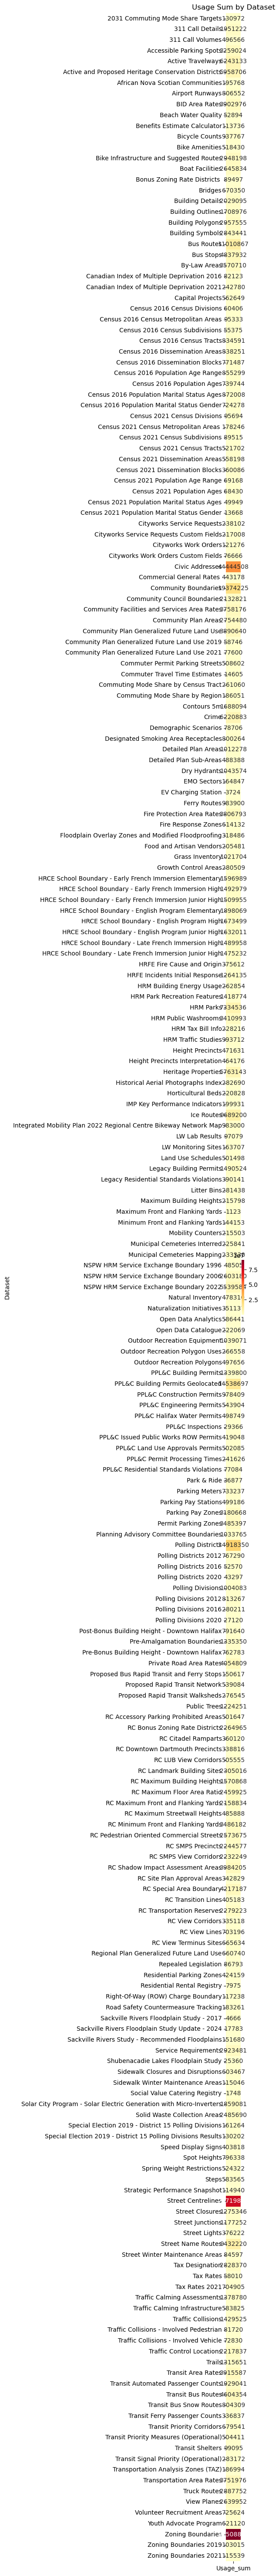

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0) (Optional) Clean up column names from Excel quirks
df.columns = df.columns.str.strip()

# 1) Aggregate: sum Usage by Dataset
usage_by_dataset = (
    df.groupby('Dataset', as_index=False)['Usage']
      .sum()
      .rename(columns={'Usage': 'Usage_sum'})
)

# 2) For a heatmap, we need a 2D table; make Dataset rows and a single column
heat_df = usage_by_dataset.set_index('Dataset')[['Usage_sum']]

# 3) Plot
plt.figure(figsize=(6, max(4, len(heat_df)*0.25)))  # auto height for many datasets
sns.heatmap(
    heat_df,
    annot=True, fmt=".0f",  # remove annotations if there are many rows
    cmap="YlOrRd",          # warm colormap
    cbar=True
)
plt.title("Usage Sum by Dataset")
plt.xlabel("")              # hide since there's only one column
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


C:\Users\biauser\AppData\Local\Temp\ipykernel_4712\2167503350.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


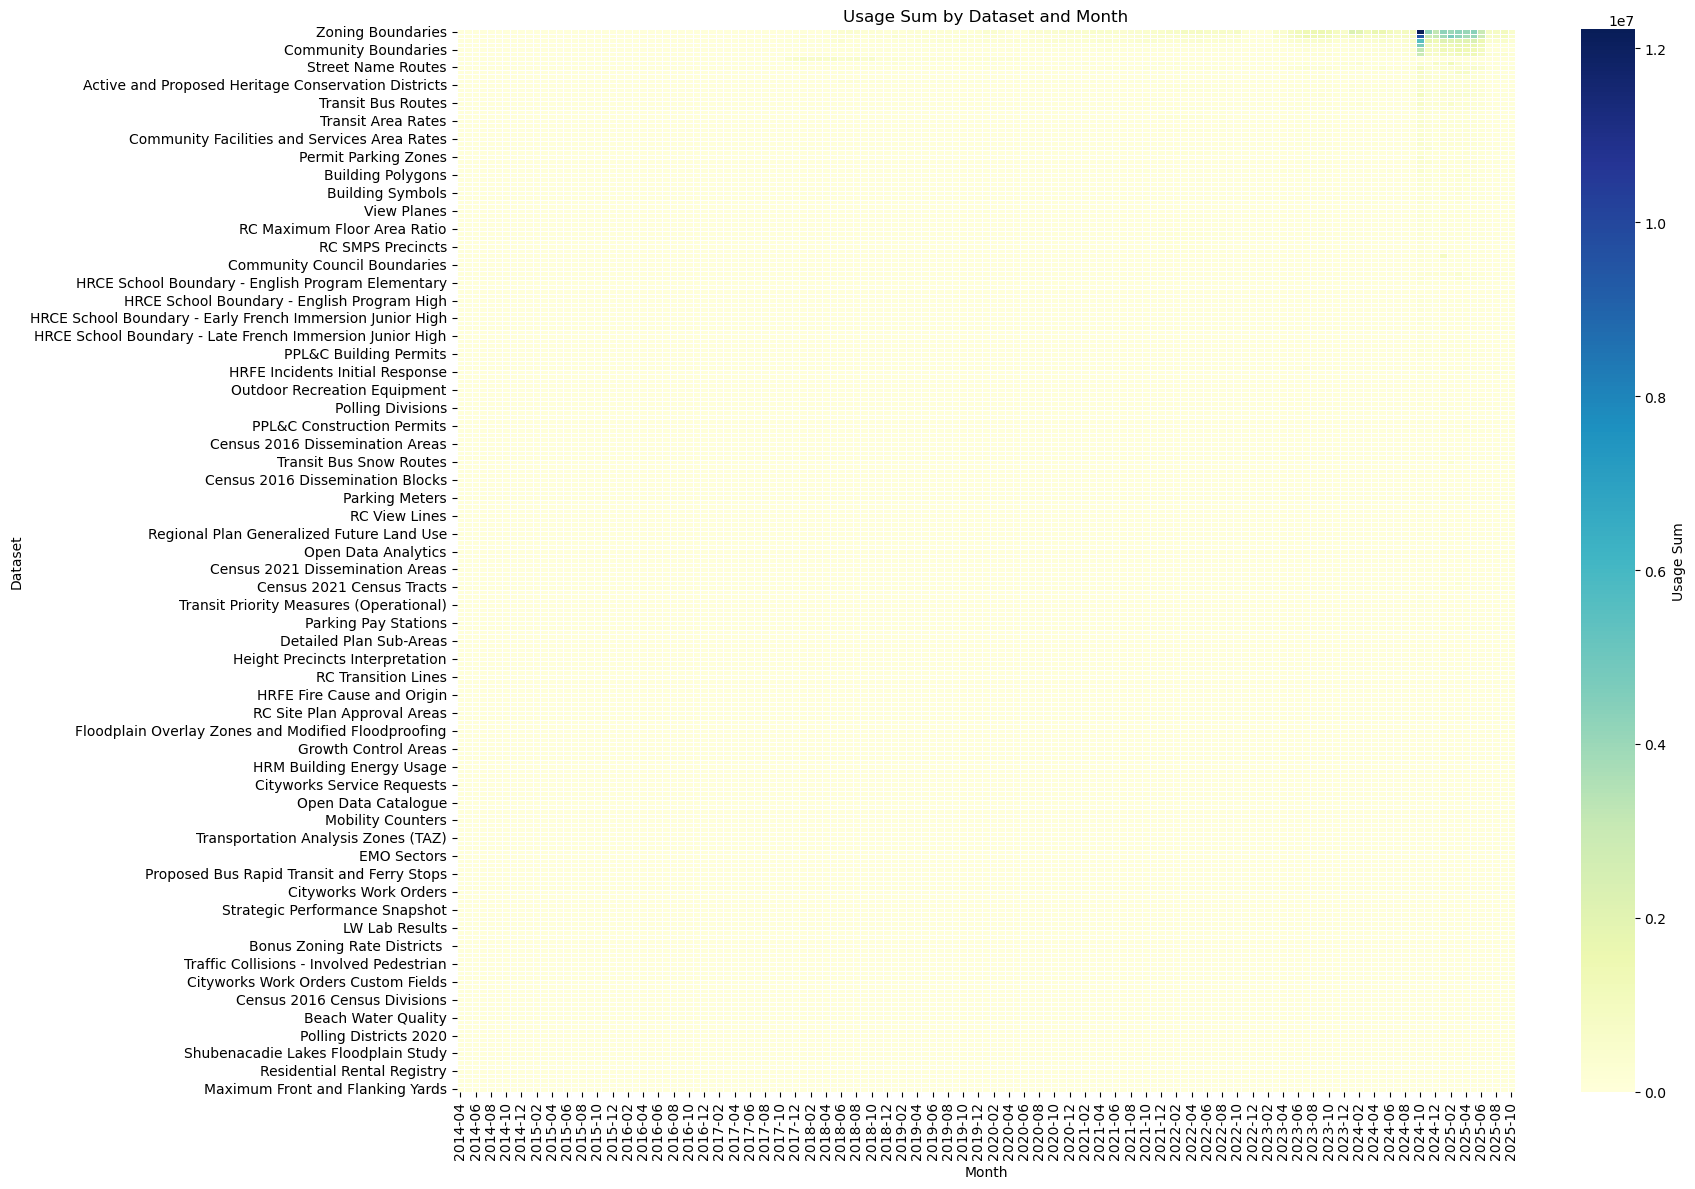

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()

# Ensure Date is datetime if you want time buckets
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Bucket by month (you can change to 'D' daily, 'Q' quarterly, etc.)
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

# Pivot to 2D matrix: rows=Dataset, cols=YearMonth, values=sum of Usage
mat = df.pivot_table(
    index='Dataset',
    columns='YearMonth',
    values='Usage',
    aggfunc='sum',
    fill_value=0
)

# Optional: sort rows by total usage
mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(min(18, 2 + 0.5*mat.shape[1]), min(12, 4 + 0.25*mat.shape[0])))
sns.heatmap(
    mat,
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Usage Sum'}
)
plt.title("Usage Sum by Dataset and Month")
plt.xlabel("Month")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()

In [14]:
topN = df.groupby('Dataset')['Usage'].sum().nlargest(30).index
df_top = df[df['Dataset'].isin(topN)]

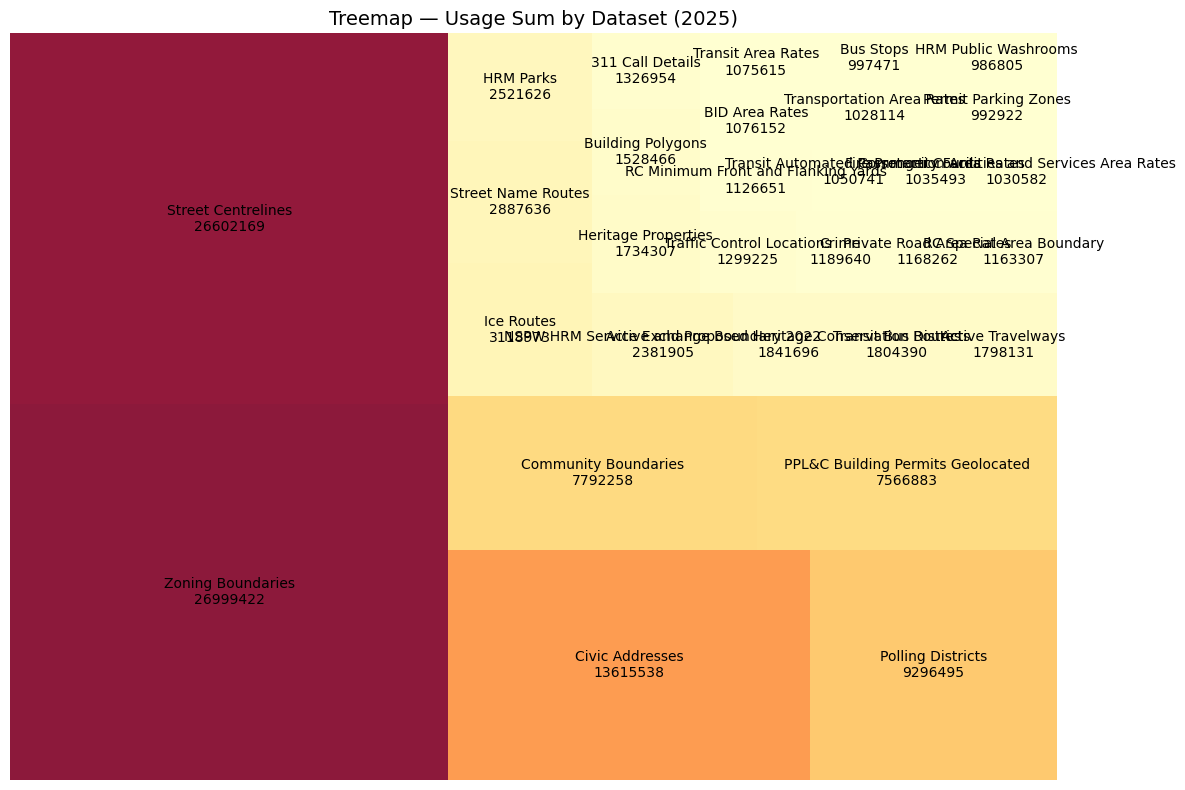

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify  # treemap helper

# Clean columns and ensure 2025 filter
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_2025 = df[df['Date'].dt.year == 2025].copy()

# Aggregate
usage_2025 = (
    df_2025.groupby('Dataset', as_index=False)['Usage']
           .sum()
           .rename(columns={'Usage': 'Usage_sum_2025'})
)

# Optional: keep top N to avoid tiny unreadable tiles
topN = 30
usage_2025 = usage_2025.nlargest(topN, 'Usage_sum_2025')

# Prepare data for treemap
sizes = usage_2025['Usage_sum_2025'].tolist()
labels = (usage_2025['Dataset'] + "\n" +
          usage_2025['Usage_sum_2025'].round(0).astype(int).astype(str)).tolist()

# Plot
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=sizes,
    label=labels,
    alpha=0.9,
    color=plt.cm.YlOrRd(
        (pd.Series(sizes) - min(sizes)) / (max(sizes) - min(sizes) if max(sizes) > min(sizes) else 1)
    )
)
plt.title("Treemap — Usage Sum by Dataset (2025)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

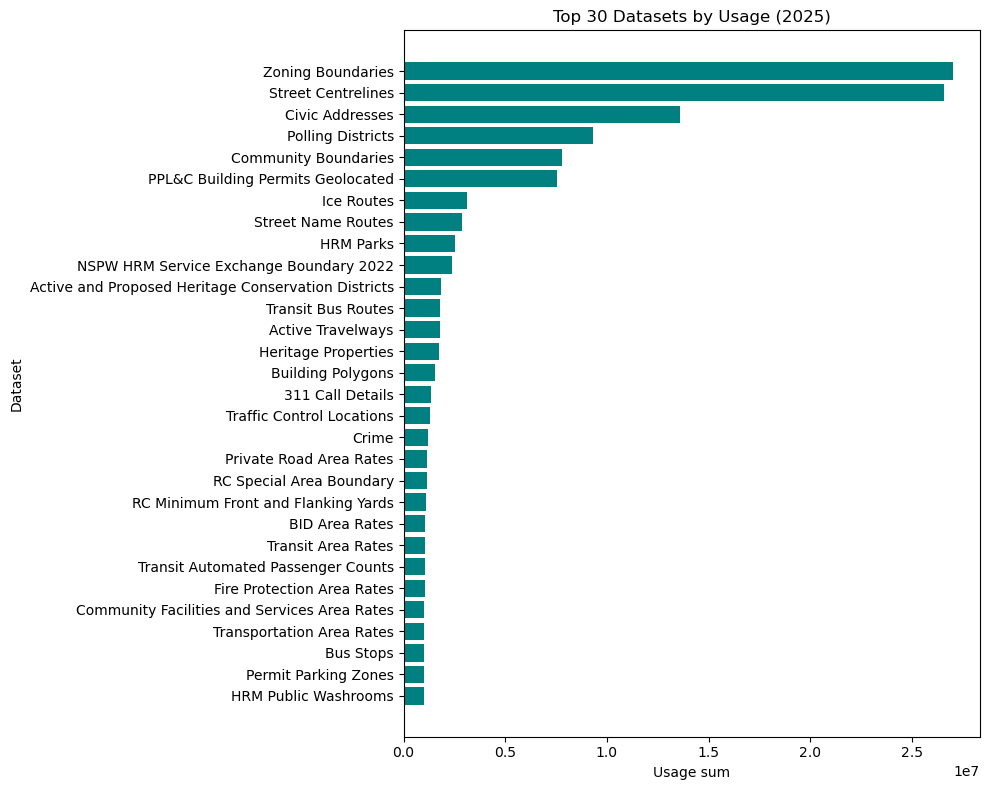

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_2025 = df[df['Date'].dt.year == 2025].copy()

usage_2025 = df_2025.groupby('Dataset', as_index=False)['Usage'].sum()
usage_2025 = usage_2025.sort_values('Usage', ascending=True).tail(30)

plt.figure(figsize=(10, 8))
plt.barh(usage_2025['Dataset'], usage_2025['Usage'], color='teal')
plt.title('Top 30 Datasets by Usage (2025)')
plt.xlabel('Usage sum')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()